In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping # <-- 1. Import it
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [19]:
# --- 1. Load Pre-Windowed Data ---
print("Loading data from .npy files...")
try:
    # We add 'allow_pickle=True' to fix potential loading errors
    X_train_full = np.load("X_train.npy", allow_pickle=True)
    y_train_full = np.load("y_train.npy", allow_pickle=True)
    
    X_test = np.load("X_test.npy", allow_pickle=True)
    y_test = np.load("y_test.npy", allow_pickle=True)
    
except FileNotFoundError:
    print("Error: .npy files not found. Please run the 'create_sequences' script first.")
    exit()

print("Original data shapes:")
print(f"X_train_full shape: {X_train_full.shape} | y_train_full shape: {y_train_full.shape}")
print(f"X_test shape: {X_test.shape}   | y_test shape: {y_test.shape}")

# --- 2. Create a Dedicated Validation Set ---
print("\nCreating validation set...")
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=0.2, # 20% of the training data will be used for validation
    random_state=42, 
    stratify=y_train_full # Stratify to keep class balance
)

print("split shapes:")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}   | y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}    | y_test shape: {y_test.shape}")

Loading data from .npy files...
Original data shapes:
X_train_full shape: (11766, 3, 9) | y_train_full shape: (11766,)
X_test shape: (2942, 3, 9)   | y_test shape: (2942,)

Creating validation set...
split shapes:
X_train shape: (9412, 3, 9) | y_train shape: (9412,)
X_val shape: (2354, 3, 9)   | y_val shape: (2354,)
X_test shape: (2942, 3, 9)    | y_test shape: (2942,)


In [20]:
# --- 3. Define Model Architecture ---
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    LSTM(units=50, return_sequences=True), 
    Dropout(0.2),
    LSTM(units=50, return_sequences=False), 
    Dropout(0.2),
    Dense(units=25, activation='tanh'),
    Dense(units=1, activation='sigmoid')
])

model.summary()

# --- 4. Handle Class Imbalance ---
print("\nCalculating class weights from the new training set...")
weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {0: weights[0], 1: weights[1]}
print(f"Class weights: {class_weights_dict}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 3, 50)               │          12,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 3, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,501 (130.86 KB)

 Trainable params: 33,501 (130.86 KB)

 Non-trainable params: 0 (0.00 B)


Calculating class weights from the new training set...
Class weights: {0: np.float64(0.6223221370007934), 1: np.float64(2.543783783783784)}


In [21]:
# --- 5. Compile the Model ---
print("Compiling model...")
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

Compiling model...


In [ ]:

early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=10,         
    verbose=1,           
    restore_best_weights=True 
)

print("Training model...")
history = model.fit(
    X_train,
    y_train,
    epochs=200, 
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights_dict,
    callbacks=[early_stopping_callback],
    verbose=1
)

Setting up EarlyStopping callback...
Training model...
Epoch 1/200
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.5986 - auc: 0.6738 - loss: 0.6428 - precision: 0.2814 - recall: 0.6708 - val_accuracy: 0.6143 - val_auc: 0.7008 - val_loss: 0.6290 - val_precision: 0.2930 - val_recall: 0.6803
Epoch 2/200
295/295 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6122 - auc: 0.7058 - loss: 0.6174 - precision: 0.2946 - recall: 0.6978 - val_accuracy: 0.5879 - val_auc: 0.7073 - val_loss: 0.6303 - val_precision: 0.2861 - val_recall: 0.7322
Epoch 3/200
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6126 - auc: 0.7196 - loss: 0.6071 - precision: 0.3025 - recall: 0.7432 - val_accuracy: 0.5811 - val_auc: 0.7181 - val_loss: 0.6346 - val_precision: 0.2896 - val_recall: 0.7775
Epoch 4/200
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6142 - auc: 0.7379 - loss: 0.5935 - precision: 0.3080 - recall: 0.7724 - val_accuracy: 0.6240 - val_auc: 0.7321 - val_loss: 0.5987 - val_precisi

In [ ]:

results = model.evaluate(X_test, y_test, verbose=1)
print("Test Loss, Test Accuracy, Test AUC, Test Precision, Test Recall:")
print(results)


Evaluating model on the *pristine* test data...
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8474 - auc: 0.8996 - loss: 0.3613 - precision: 0.5834 - recall: 0.7803
Test Loss, Test Accuracy, Test AUC, Test Precision, Test Recall:
[0.3612985908985138, 0.8473827242851257, 0.8996075987815857, 0.5834411382675171, 0.7802768349647522]


Plotting training history...
Saved training history plot to 'model_training_history_tanh.png'


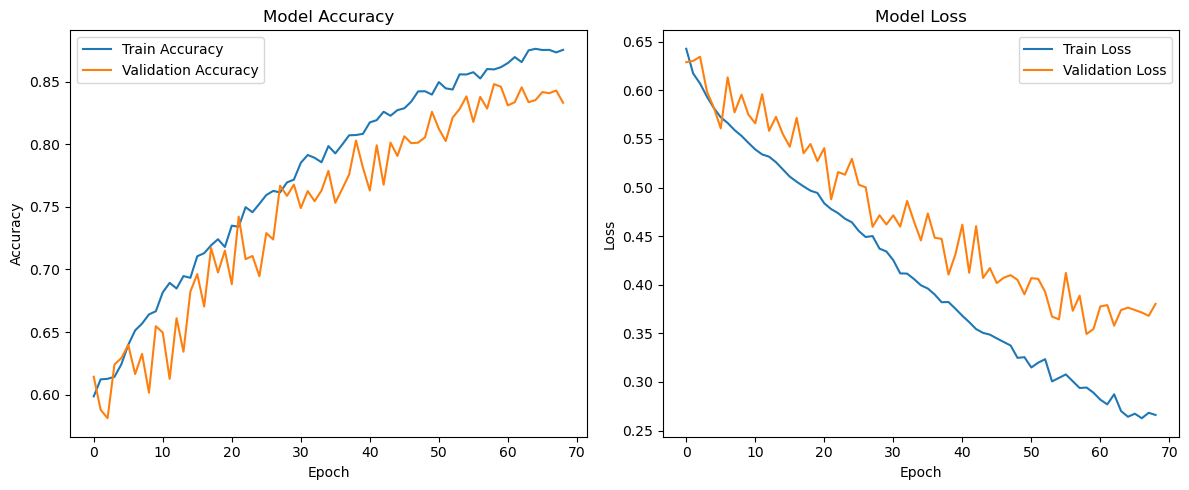

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("model_training_history_tanh.png")
print("Saved training history plot to 'model_training_history_tanh.png'")